In [1]:
# 1) Loading The Taxis DataSet

import seaborn as sns
import pandas as pd

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

print(df.head())
print(df.shape)

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [2]:
# 2) Handing Missing Values

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())
print("\nPercentage of missing values:\n", (df.isnull().sum() / len(df)) * 100)

# Identify columns with missing data
cols_with_missing = df.columns[df.isnull().any()].tolist()
print("\nColumns with missing data:", cols_with_missing)

# Detailed info about the dataset to see column types
print("\nDataset Info:")
print(df.info())

# Describe to understand numeric columns
print(df.describe())

# --- IMPUTATION STRATEGY ---

# For numerical columns -> use median (better than mean for skewed taxi data)
# For categorical columns -> use mode

# Make a copy for cleaning
df_cleaned = df.copy()

# 1. Numerical columns: e.g., 'distance', 'tip', 'tolls', 'total' if present
numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")

# 2. Categorical columns: e.g., 'payment', 'color', 'pickup_zone' etc.
categorical_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

# 3. For critical columns that cannot be reasonably imputed, remove rows
# Example: 'pickup' and 'dropoff' time, or 'passengers' are critical
# If after imputation still missing in critical columns, drop them

critical_columns = ['pickup', 'dropoff', 'passengers'] # adjust based on your dataset version
# Only keep critical columns that exist in df
critical_columns = [c for c in critical_columns if c in df_cleaned.columns]

df_cleaned.dropna(subset=critical_columns, inplace=True)

print("\nAfter handling missing values:")
print(df_cleaned.isnull().sum())
print("\nFinal shape:", df_cleaned.shape)

Missing values per column:
 pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Percentage of missing values:
 pickup             0.000000
dropoff            0.000000
passengers         0.000000
distance           0.000000
fare               0.000000
tip                0.000000
tolls              0.000000
total              0.000000
color              0.000000
payment            0.683973
pickup_zone        0.404166
dropoff_zone       0.699518
pickup_borough     0.404166
dropoff_borough    0.699518
dtype: float64

Columns with missing data: ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (t

/tmp/ipykernel_1967/3759097835.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(mode_val, inplace=True)


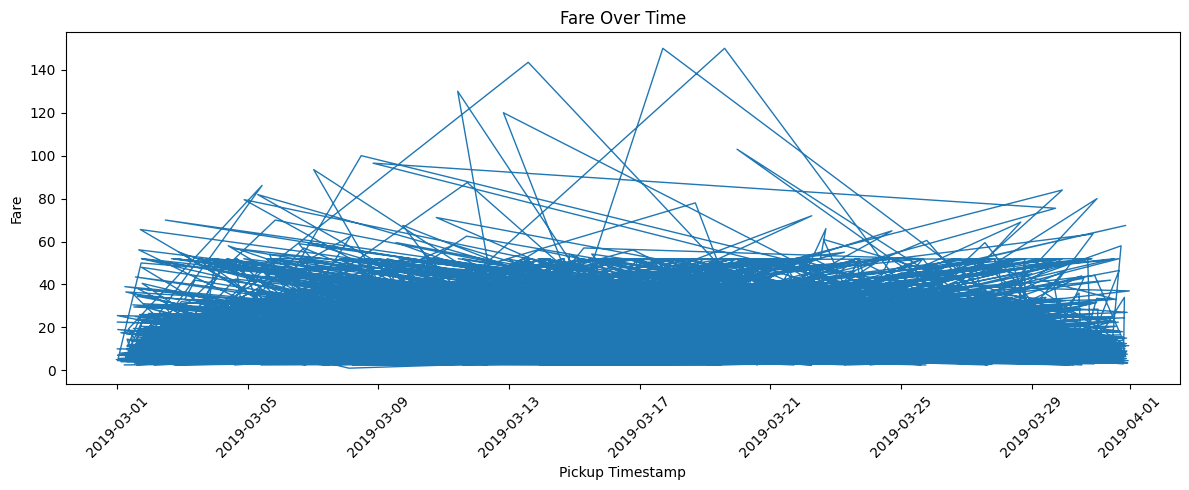

In [3]:
# 3) Visualization using Matplotlib/pandas plot:

import matplotlib.pyplot as plt


# ---------------------------------------------------
# 1. Line Chart - Fare over time
plt.figure(figsize=(12, 5))
plt.plot(df_cleaned['pickup'], df_cleaned['fare'], linewidth=1)
plt.xlabel('Pickup Timestamp')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



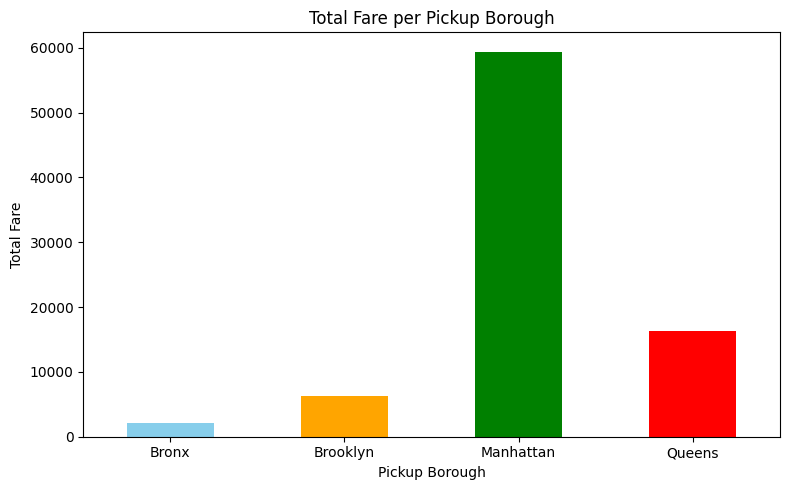

In [4]:
# ---------------------------------------------------
# 2. Bar Chart - Total fare for each pickup_borough
fare_by_borough = df_cleaned.groupby('pickup_borough')['fare'].sum()

plt.figure(figsize=(8, 5))
fare_by_borough.plot(kind='bar', color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare per Pickup Borough')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

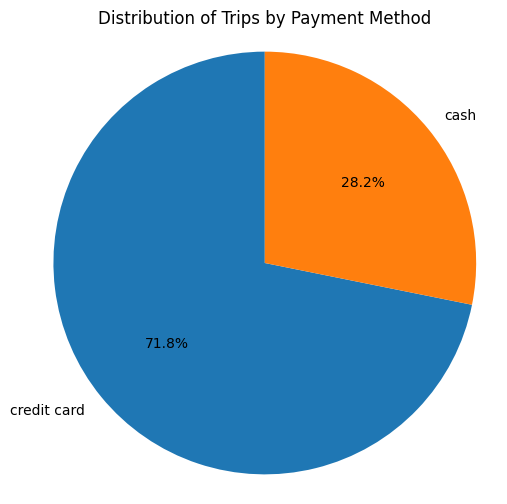

In [5]:
# ---------------------------------------------------
# 3. Pie Chart - Distribution of trips by payment method
payment_counts = df_cleaned['payment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Trips by Payment Method')
plt.axis('equal') # Equal aspect ratio ensures pie is circular
plt.show()

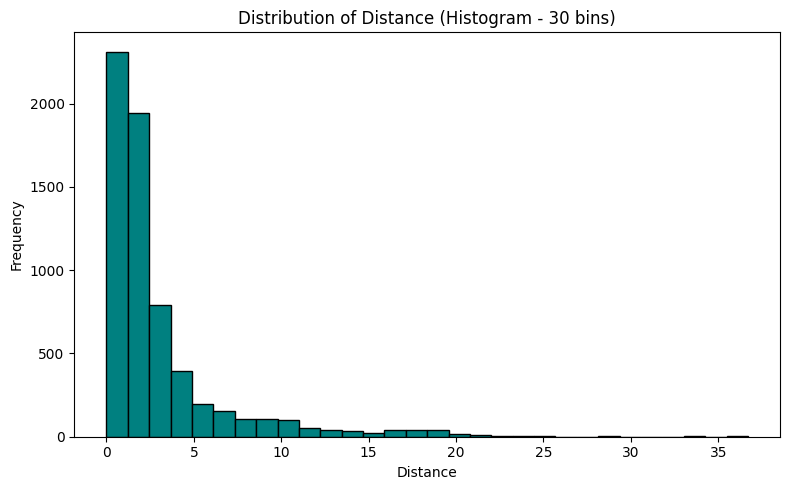

In [6]:
# ---------------------------------------------------
# 4. Histogram - Distribution of distance
plt.figure(figsize=(8, 5))
plt.hist(df_cleaned['distance'], bins=30, color='teal', edgecolor='black')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Distance (Histogram - 30 bins)')
plt.tight_layout()
plt.show()

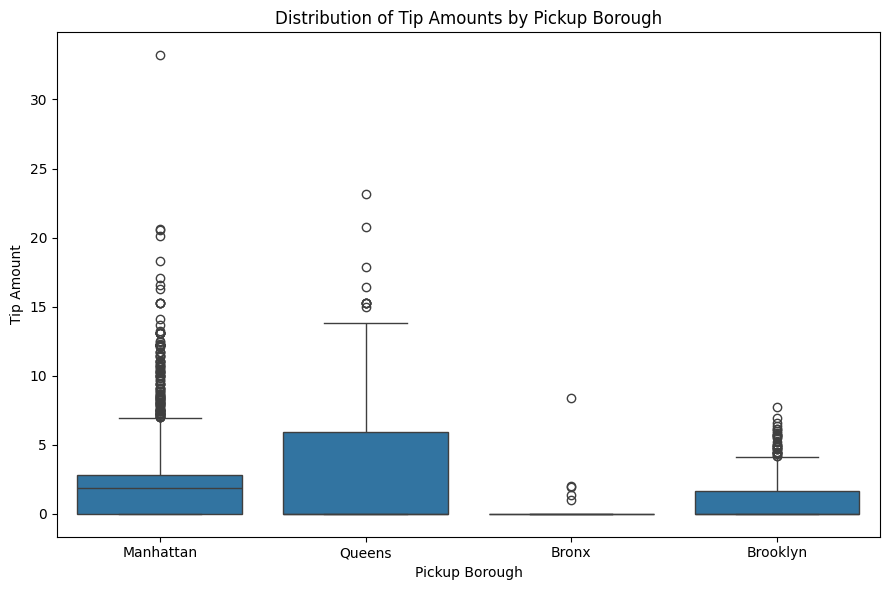

In [7]:

# ---------------------------------------------------
# 5) Box Plot - Tip amount for each pickup_borough

plt.figure(figsize=(9, 6))
sns.boxplot(x='pickup_borough', y='tip', data=df_cleaned)
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.tight_layout()
plt.show()



/tmp/ipykernel_1967/1047768911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_borough', data=df_cleaned, palette='viridis')


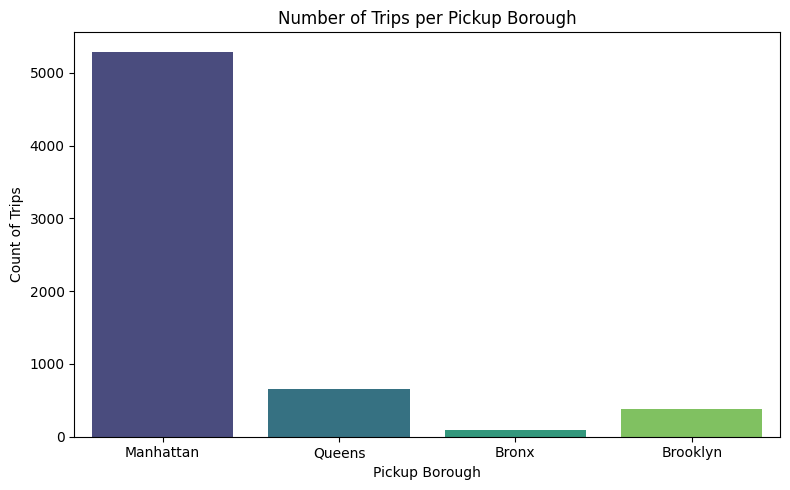

In [8]:
# 4) Visualization Using Seaborn:

# 1. Count Plot - Number of trips in each pickup_borough

plt.figure(figsize=(8,5))
sns.countplot(x='pickup_borough', data=df_cleaned, palette='viridis')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.title('Number of Trips per Pickup Borough')
plt.tight_layout()
plt.show()



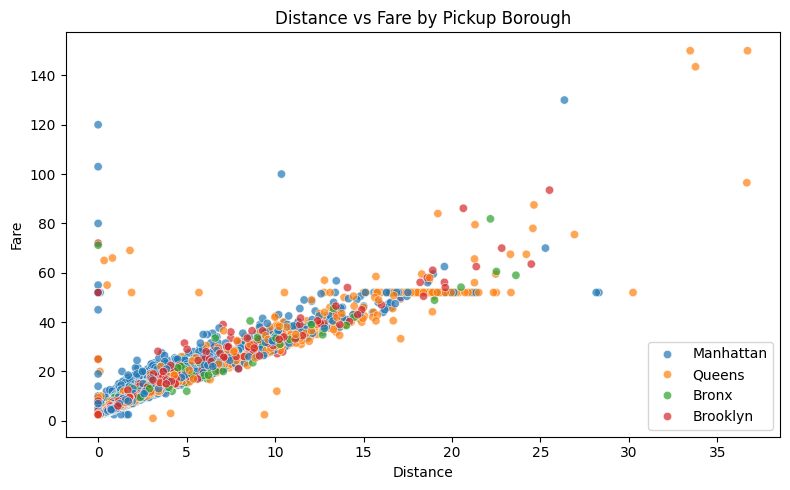

In [9]:
# ---------------------------------------------------
# 2. Scatter Plot - Relationship between distance and fare

plt.figure(figsize=(8,5))
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df_cleaned, alpha=0.7)
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Distance vs Fare by Pickup Borough')
plt.legend()
plt.tight_layout()
plt.show()


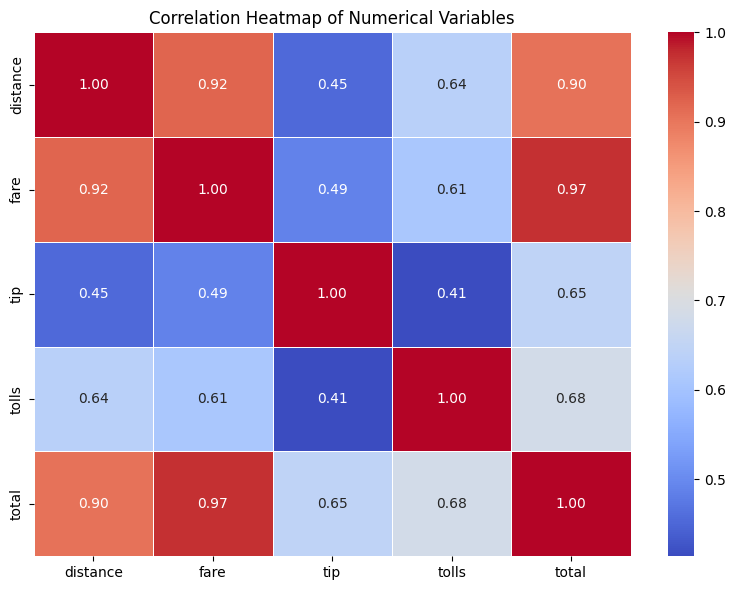

In [10]:
# ---------------------------------------------------
# 3. Heatmap - Correlation between numerical variables

plt.figure(figsize=(8,6))
# Select only numeric columns
numeric_cols = df_cleaned[['distance', 'fare', 'tip', 'tolls', 'total']]
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

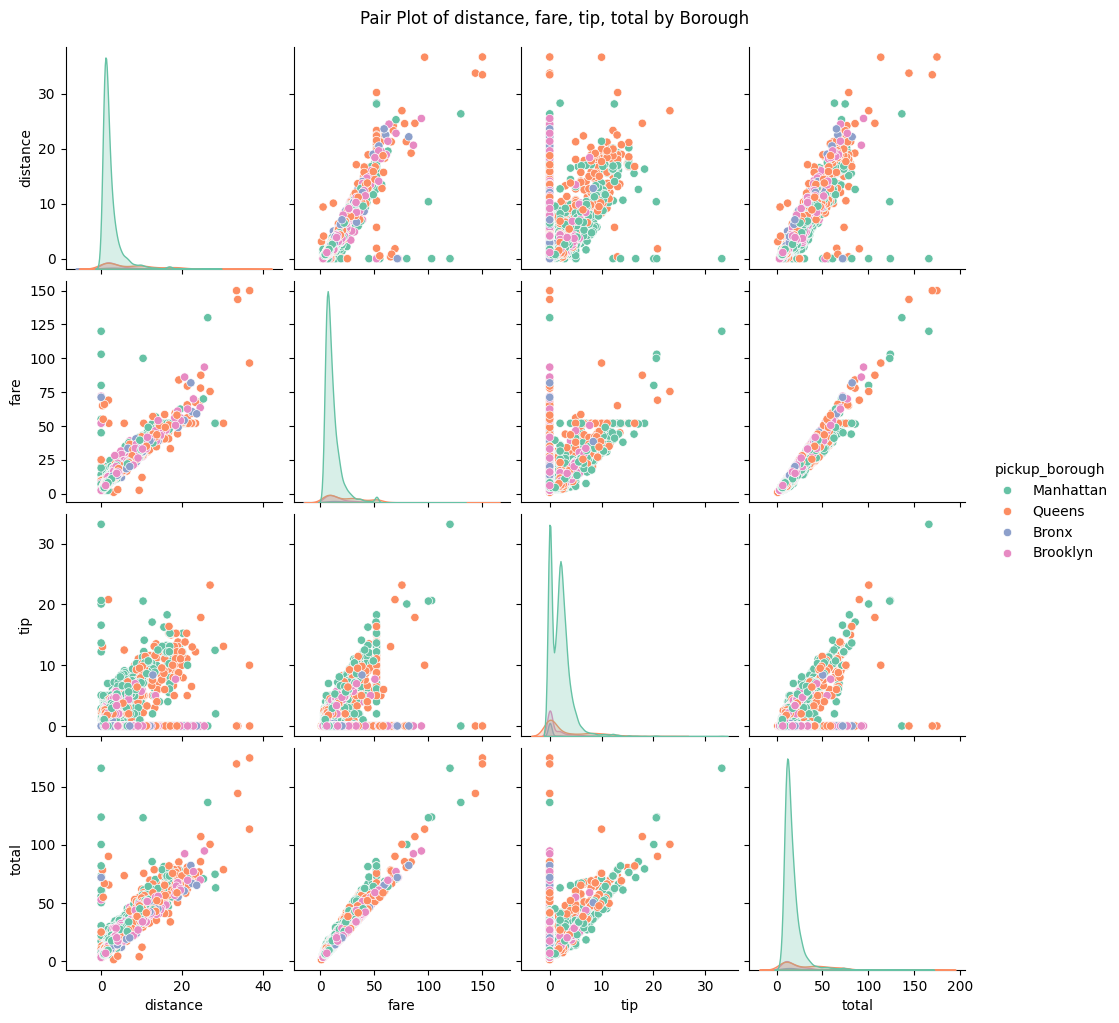

In [11]:
# 4. Pair Plot - Pairwise relationships



sns.pairplot(df_cleaned, vars=['distance', 'fare', 'tip', 'total'],
             hue='pickup_borough', diag_kind='kde', palette='Set2')
plt.suptitle('Pair Plot of distance, fare, tip, total by Borough', y=1.02)
plt.show()

/tmp/ipykernel_1967/401396916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='payment', y='fare', data=df_cleaned, palette='Set3', inner='quartile')


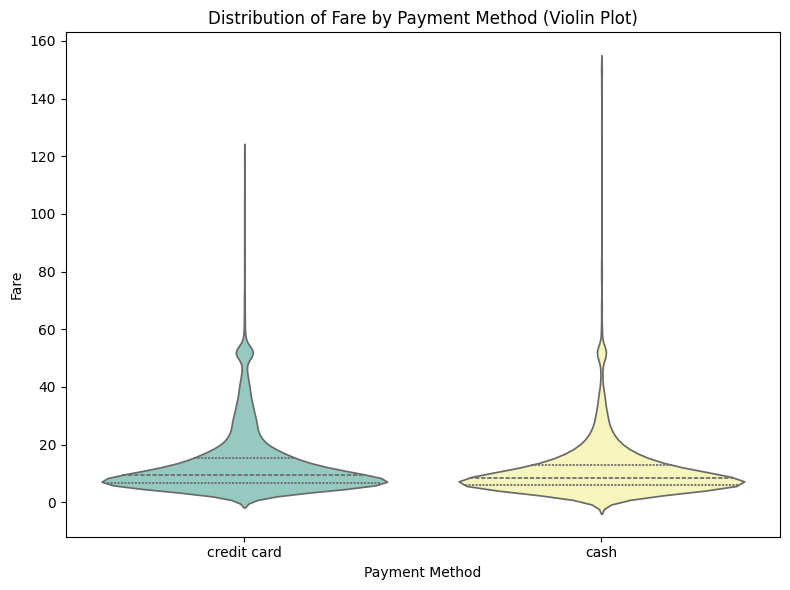

In [12]:

# 5) Violin Plot - Distribution of fare for each payment method
plt.figure(figsize=(8, 6))
sns.violinplot(x='payment', y='fare', data=df_cleaned, palette='Set3', inner='quartile')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Distribution of Fare by Payment Method (Violin Plot)')
plt.tight_layout()
plt.show()